<a href="https://colab.research.google.com/github/hritikac25/fentanyl_overdose_covid/blob/main/OverdoseTrends_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files


uploaded = files.upload()

Saving overdoses-latest.csv to overdoses-latest.csv


In [ ]:
import pandas as pd



df_raw = pd.read_csv("overdoses-latest.csv", low_memory=False)

# fentanyl-related cases
df_fentanyl = df_raw[df_raw["Fentanyl"] == 1].copy()

# standardize Gender
df_fentanyl["Gender"] = df_fentanyl["Gender"].str.upper().map({
    "MALE": "MALE", "M": "MALE",
    "FEMALE": "FEMALE", "F": "FEMALE",
    "NON-BINARY": "NON-BINARY", "NB": "NON-BINARY"
}).fillna("NON-BINARY")

#standardize Race
df_fentanyl["Race"] = df_fentanyl["Race"].str.upper().fillna("UNKNOWN")

# Parse DeathDate and create Post_COVID flag
df_fentanyl["DeathDate"] = pd.to_datetime(df_fentanyl["DeathDate"], errors="coerce")
df_fentanyl["Post_COVID"] = df_fentanyl["DeathDate"] >= pd.to_datetime("2020-03-01")

# Clean Age and bin into groups
df_fentanyl["Age"] = pd.to_numeric(df_fentanyl["Age"], errors="coerce")
age_bins = [0, 17, 24, 34, 44, 54, 64, float("inf")]
age_labels = ["0-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df_fentanyl["AgeGroup"] = pd.cut(df_fentanyl["Age"], bins=age_bins, labels=age_labels, right=False)

# recode experiencing homelessness as Yes/No
df_fentanyl["Homeless"] = df_fentanyl["ExperiencingHomelessness"].apply(lambda x: "Yes" if pd.notna(x) else "No")

# Standardize ResidenceType
df_fentanyl["ResidenceType"] = df_fentanyl["ResidenceType"].str.upper().fillna("UNKNOWN")

# Dropping unusable rows
df_cleaned = df_fentanyl.dropna(subset=["Age", "Gender", "Race", "DeathDate"]).reset_index(drop=True)


<ipython-input-8-6439d84c3705>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby([group_col, "Post_COVID"]).size().unstack(fill_value=0)


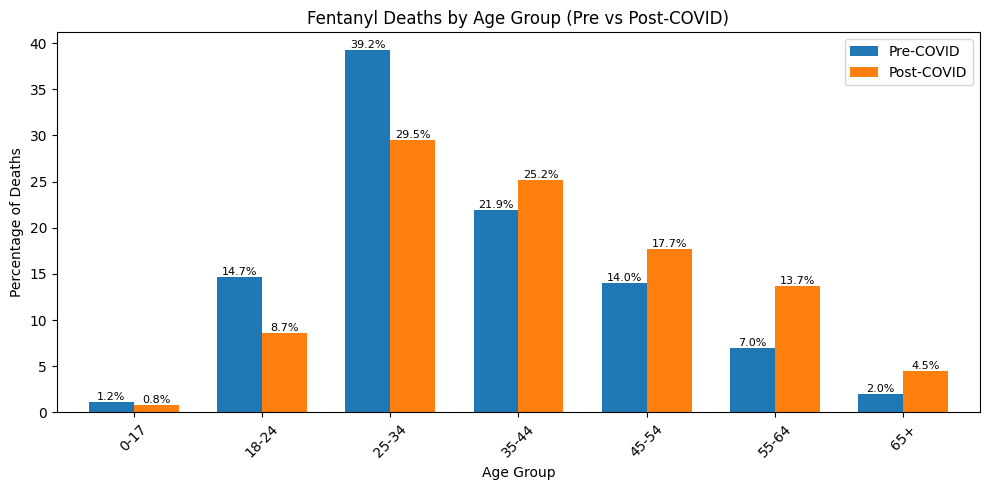

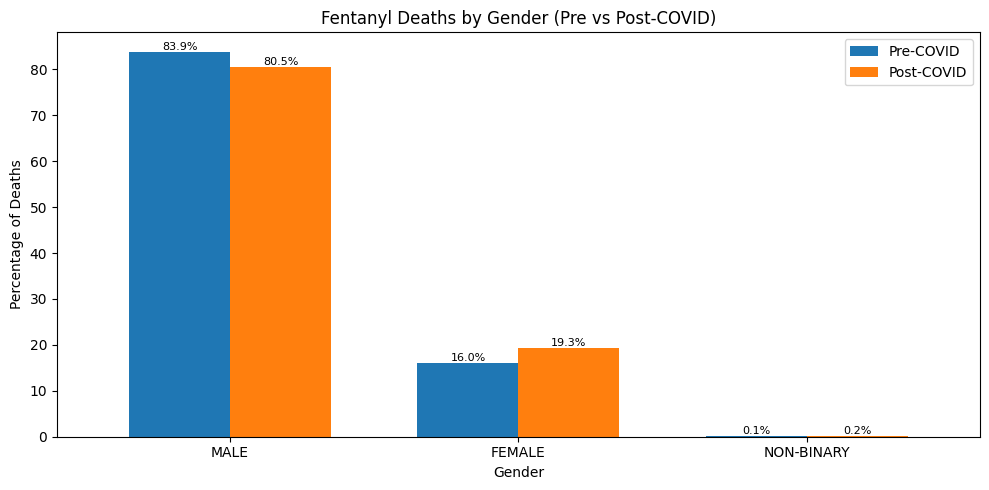

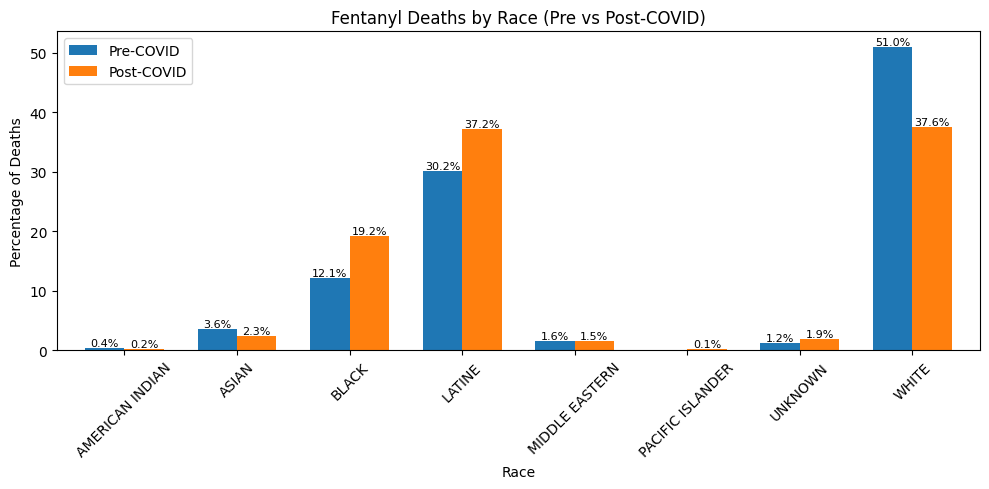

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Demographic shifts

# Group and Normalize
def percentage_distribution(df, group_col):
    counts = df.groupby([group_col, "Post_COVID"]).size().unstack(fill_value=0)
    percent = counts.div(counts.sum(axis=0), axis=1) * 100
    return percent

# Generating distributions from cleaned dataset
age_percent = percentage_distribution(df_cleaned, "AgeGroup")
gender_percent = percentage_distribution(df_cleaned, "Gender").reindex(["MALE", "FEMALE", "NON-BINARY"])
race_percent = percentage_distribution(df_cleaned, "Race")

# Plotting Function
def plot_percentage_bars(data, title, xlabel):
    ax = data.plot(kind="bar", figsize=(10, 5), width=0.7)
    for i, container in enumerate(ax.containers):
        labels = [f"{v:.1f}%" if v > 0 else "" for v in data.iloc[:, i]]
        ax.bar_label(container, labels=labels, label_type="edge", fontsize=8)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Percentage of Deaths")
    plt.xticks(rotation=45 if xlabel != "Gender" else 0)
    plt.legend(["Pre-COVID", "Post-COVID"])
    plt.tight_layout()
    plt.show()

# Generate Plots
plot_percentage_bars(age_percent, "Fentanyl Deaths by Age Group (Pre vs Post-COVID)", "Age Group")
plot_percentage_bars(gender_percent, "Fentanyl Deaths by Gender (Pre vs Post-COVID)", "Gender")
plot_percentage_bars(race_percent, "Fentanyl Deaths by Race (Pre vs Post-COVID)", "Race")


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# run proportion z-tests for all subgroups in a category
def run_subgroup_tests(df, col_name):
    results = []
    subgroups = df[col_name].dropna().unique()
    pre_total = df[df["Post_COVID"] == False].shape[0]
    post_total = df[df["Post_COVID"] == True].shape[0]

    for subgroup in subgroups:
        pre_count = df[(df["Post_COVID"] == False) & (df[col_name] == subgroup)].shape[0]
        post_count = df[(df["Post_COVID"] == True) & (df[col_name] == subgroup)].shape[0]
        count = [post_count, pre_count]
        nobs = [post_total, pre_total]

        try:
            z_stat, p_val = proportions_ztest(count, nobs)
        except Exception as e:
            z_stat, p_val = None, None

        results.append({
            col_name: subgroup,
            "Pre-COVID Proportion": pre_count / pre_total,
            "Post-COVID Proportion": post_count / post_total,
            "Z-Statistic": z_stat,
            "p-value": p_val
        })

    return pd.DataFrame(results).sort_values("p-value")

# Run tests
race_results = run_subgroup_tests(df_cleaned, "Race")
gender_results = run_subgroup_tests(df_cleaned, "Gender")
age_results = run_subgroup_tests(df_cleaned, "AgeGroup")

# results
print("RACE")
print(race_results)

print("\nGENDER")
print(gender_results)

print("\nAGE GROUP")
print(age_results)


RACE
               Race  Pre-COVID Proportion  Post-COVID Proportion  Z-Statistic  \
0             WHITE              0.510482               0.375526    -8.003057   
3             BLACK              0.120545               0.192113     5.353504   
1            LATINE              0.301887               0.372046     4.222490   
2             ASIAN              0.035639               0.022909    -2.386104   
4           UNKNOWN              0.011530               0.018994     1.621281   
6   AMERICAN INDIAN              0.004193               0.002175    -1.188989   
7  PACIFIC ISLANDER              0.000000               0.001305     1.116386   
5    MIDDLE EASTERN              0.015723               0.014934    -0.187785   

        p-value  
0  1.213674e-15  
3  8.626712e-08  
1  2.416177e-05  
2  1.702795e-02  
4  1.049573e-01  
6  2.344441e-01  
7  2.642569e-01  
5  8.510450e-01  

GENDER
       Gender  Pre-COVID Proportion  Post-COVID Proportion  Z-Statistic  \
0        MALE       

📊 Linear Regression Evaluation:
Mean Absolute Error (MAE): 3.49
Root Mean Squared Error (RMSE): 4.73
R² Score: 0.64


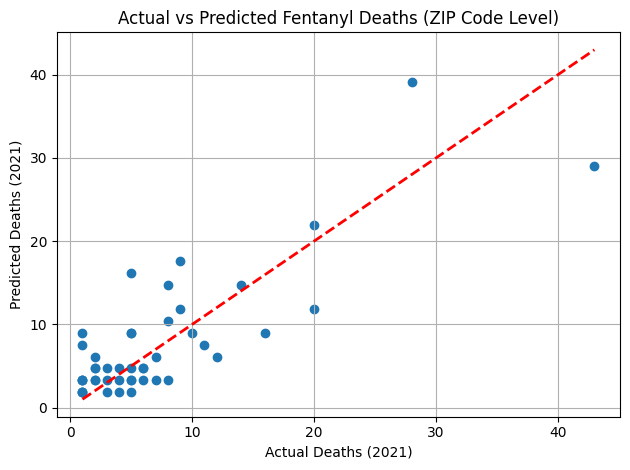

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Extract year
df_cleaned["Year"] = df_cleaned["DeathDate"].dt.year

# Using only 2020 and 2021
df_cleaned["ZIPCODE"] = pd.to_numeric(df_cleaned["ZIPCODE"], errors="coerce")
df_model = df_cleaned[df_cleaned["Year"].isin([2020, 2021])].dropna(subset=["ZIPCODE"])

# by ZIP and year
zip_year_deaths = df_model.groupby(["ZIPCODE", "Year"]).size().reset_index(name="Deaths")

# to get 2020 as feature and 2021 as target
zip_pivot = zip_year_deaths.pivot(index="ZIPCODE", columns="Year", values="Deaths").dropna()
zip_pivot.columns = ["Deaths_2020", "Deaths_2021"]
zip_pivot = zip_pivot.reset_index()

# Define feature and target
X = zip_pivot[["Deaths_2020"]]
y = zip_pivot["Deaths_2021"]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📊 Linear Regression Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Plot predictions
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Deaths (2021)")
plt.ylabel("Predicted Deaths (2021)")
plt.title("Actual vs Predicted Fentanyl Deaths (ZIP Code Level)")
plt.grid(True)
plt.tight_layout()
plt.show()

#Our model using only 2020 overdose deaths explains 64% of
#the variation in 2021 deaths, suggesting strong year-to-year consistency at the ZIP level.

In [ ]:
pip install prophet xgboost scikit-learn pandas matplotlib

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Monthly ZIP-level fentanyl deaths
df_cleaned["Month"] = df_cleaned["DeathDate"].dt.to_period("M").dt.to_timestamp()
df_zip_month = df_cleaned.groupby(["ZIPCODE", "Month"]).size().reset_index(name="Deaths")
df_zip_month = df_zip_month.sort_values(["ZIPCODE", "Month"])

# Create lag features
for lag in range(1, 7):
    df_zip_month[f"Deaths_lag{lag}"] = df_zip_month.groupby("ZIPCODE")["Deaths"].shift(lag)

# Create binary label for classification (1 = increase from previous month)
df_zip_month["DeathChange"] = df_zip_month.groupby("ZIPCODE")["Deaths"].diff()
df_zip_month["Label"] = (df_zip_month["DeathChange"] > 0).astype(int)

# Drop missing labels and merge demographics
df_class = df_zip_month.dropna(subset=["Label"]).copy()

# Merge ZIP-level demographics (from 2020)
df_class = df_class.merge(demo_features, on="ZIPCODE", how="left")

# Defining features and target
feature_cols = [f"Deaths_lag{i}" for i in range(1, 7)] + [col for col in df_class.columns if "_prop" in col]
X = df_class[feature_cols]
y = df_class["Label"]  # 1 = Increase, 0 = No increase

# Balance the dataset (undersample majority class)
from sklearn.utils import resample
df_pos = df_class[df_class["Label"] == 1]
df_neg = df_class[df_class["Label"] == 0]
df_neg_bal = resample(df_neg, replace=False, n_samples=len(df_pos), random_state=42)
df_balanced = pd.concat([df_pos, df_neg_bal])

X_bal = df_balanced[feature_cols]
y_bal = df_balanced["Label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

#Final XGBoost Classifier tuned for recall
xgb_clf_final = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.5,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Fit and evaluate
xgb_clf_final.fit(X_train, y_train)
y_pred_final = xgb_clf_final.predict(X_test)

# Metrics
print("📊 Final Surge Classifier Performance")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))


📊 Final Surge Classifier Performance
Confusion Matrix:
 [[ 97 100]
 [ 47 173]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.49      0.57       197
           1       0.63      0.79      0.70       220

    accuracy                           0.65       417
   macro avg       0.65      0.64      0.64       417
weighted avg       0.65      0.65      0.64       417



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:48:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
pip install imbalanced-learn xgboost scikit-learn pandas numpy matplotlib


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Load your cleaned data
df = pd.read_csv("overdoses-latest.csv", low_memory=False)
df = df[df["Fentanyl"] == 1].copy()
df["DeathDate"] = pd.to_datetime(df["DeathDate"], errors="coerce")
df["ZIPCODE"] = pd.to_numeric(df["ZIPCODE"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Month"] = df["DeathDate"].dt.to_period("M").dt.to_timestamp()
df["Year"] = df["DeathDate"].dt.year
df = df.dropna(subset=["DeathDate", "ZIPCODE"])

# Create ZIP-level monthly counts
df_zip = df.groupby(["ZIPCODE", "Month"]).size().reset_index(name="Deaths")
df_zip = df_zip.sort_values(["ZIPCODE", "Month"])

# Lag features
for i in range(1, 7):
    df_zip[f"Deaths_lag{i}"] = df_zip.groupby("ZIPCODE")["Deaths"].shift(i)

# Moving average + cyclic month features
df_zip["Deaths_avg3"] = df_zip[["Deaths_lag1", "Deaths_lag2", "Deaths_lag3"]].mean(axis=1)
df_zip["MonthNum"] = df_zip["Month"].dt.month
df_zip["Month_sin"] = np.sin(2 * np.pi * df_zip["MonthNum"] / 12)
df_zip["Month_cos"] = np.cos(2 * np.pi * df_zip["MonthNum"] / 12)

# Create binary label: 1 = increase, 0 = decrease (drop equal)
df_zip["DeathChange"] = df_zip.groupby("ZIPCODE")["Deaths"].diff()
df_zip = df_zip[df_zip["DeathChange"] != 0]
df_zip["Label"] = (df_zip["DeathChange"] > 0).astype(int)
df_zip = df_zip.dropna()

# Demographic features from 2020
df_2020 = df[df["Year"] == 2020].copy()
def get_props(df, col):
    counts = df.groupby(["ZIPCODE", col]).size().unstack(fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)

gender_props = get_props(df_2020, "Gender")
race_props = get_props(df_2020, "Race")
age_bins = [0, 17, 24, 34, 44, 54, 64, float("inf")]
df_2020["AgeGroup"] = pd.cut(df_2020["Age"], bins=age_bins, labels=["0-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"], right=False)
age_props = get_props(df_2020, "AgeGroup")
homeless_props = get_props(df_2020, "ExperiencingHomelessness").rename(columns={True: "Yes", False: "No"})

# Merge demographic context
demo_df = pd.concat([gender_props, race_props, age_props, homeless_props], axis=1)
demo_df.columns = [f"{col}_prop" for col in demo_df.columns]
df_zip = df_zip.merge(demo_df, on="ZIPCODE", how="left")

# Select features
lag_feats = [f"Deaths_lag{i}" for i in range(1, 7)]
extra_feats = ["Deaths_avg3", "Month_sin", "Month_cos"]
demo_feats = [col for col in df_zip.columns if "_prop" in col]
# Drop rows with any missing values before train/test split
df_zip = df_zip.dropna(subset=lag_feats + extra_feats + demo_feats + ["Label"])
X = df_zip[lag_feats + extra_feats + demo_feats]
y = df_zip["Label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

# Train XGBoost classifier
model = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=4,
                      use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_res, y_res)

# Predict with tuned threshold
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.4).astype(int)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

import joblib
joblib.dump(model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")


Confusion Matrix:
 [[178  11]
 [ 17 148]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       189
           1       0.93      0.90      0.91       165

    accuracy                           0.92       354
   macro avg       0.92      0.92      0.92       354
weighted avg       0.92      0.92      0.92       354



<ipython-input-8-6a5e3ed94c07>:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(["ZIPCODE", col]).size().unstack(fill_value=0)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:27:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


['scaler.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Clean dataset
df = df_raw[df_raw["Fentanyl"] == 1].copy()
df["DeathDate"] = pd.to_datetime(df["DeathDate"], errors="coerce")
df["ZIPCODE"] = pd.to_numeric(df["ZIPCODE"], errors="coerce")
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Month"] = df["DeathDate"].dt.to_period("M").dt.to_timestamp()
df["Year"] = df["DeathDate"].dt.year
df = df.dropna(subset=["DeathDate", "ZIPCODE"])

# ZIP-month deaths
df_zip = df.groupby(["ZIPCODE", "Month"]).size().reset_index(name="Deaths")
df_zip = df_zip.sort_values(["ZIPCODE", "Month"])

# Lag features
for i in range(1, 7):
    df_zip[f"Deaths_lag{i}"] = df_zip.groupby("ZIPCODE")["Deaths"].shift(i)
df_zip["Deaths_avg3"] = df_zip[["Deaths_lag1", "Deaths_lag2", "Deaths_lag3"]].mean(axis=1)
df_zip["MonthNum"] = df_zip["Month"].dt.month
df_zip["Month_sin"] = np.sin(2 * np.pi * df_zip["MonthNum"] / 12)
df_zip["Month_cos"] = np.cos(2 * np.pi * df_zip["MonthNum"] / 12)

# Demographics from 2020
df_2020 = df[df["Year"] == 2020].copy()
def get_props(df, col):
    counts = df.groupby(["ZIPCODE", col]).size().unstack(fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)
gender_props = get_props(df_2020, "Gender")
race_props = get_props(df_2020, "Race")
df_2020["AgeGroup"] = pd.cut(df_2020["Age"], bins=[0, 17, 24, 34, 44, 54, 64, float("inf")],
                             labels=["0-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"], right=False)
age_props = get_props(df_2020, "AgeGroup")
homeless_props = get_props(df_2020, "ExperiencingHomelessness").rename(columns={True: "Yes", False: "No"})
demo_df = pd.concat([gender_props, race_props, age_props, homeless_props], axis=1)
demo_df.columns = [f"{col}_prop" for col in demo_df.columns]

# Merge features
df_predict = df_zip.merge(demo_df, on="ZIPCODE", how="left")
lag_feats = [f"Deaths_lag{i}" for i in range(1, 7)]
extra_feats = ["Deaths_avg3", "Month_sin", "Month_cos"]
demo_feats = [col for col in df_predict.columns if "_prop" in col]
all_feats = lag_feats + extra_feats + demo_feats
df_predict = df_predict.dropna(subset=all_feats).copy()

# Re-train model for now since the environment reset
X = df_predict[all_feats]
y = df_predict.groupby("ZIPCODE")["Deaths"].diff().fillna(0) > 0
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=4,
                      use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_scaled, y)

# Predict surge
df_predict["Surge_Prob"] = model.predict_proba(X_scaled)[:, 1]
df_predict["Surge_Predicted"] = (df_predict["Surge_Prob"] >= 0.4).astype(int)

# Output flagged ZIP-months
df_flagged = df_predict[df_predict["Surge_Predicted"] == 1][["ZIPCODE", "Month", "Surge_Prob"] + lag_feats + ["Deaths"]]
df_flagged = df_flagged.sort_values(["Month", "Surge_Prob"], ascending=[True, False])

df_flagged.head(20)

# Save the high-risk ZIP surge predictions to CSV
df_flagged.to_csv("high_risk_zip_predictions.csv", index=False)

<ipython-input-7-de1f3d20d768>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(["ZIPCODE", col]).size().unstack(fill_value=0)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:24:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
import folium
from folium.plugins import HeatMap

# Make sure df_cleaned includes lat/lon and is preloaded
df_cleaned["lat"] = pd.to_numeric(df_cleaned["lat"], errors="coerce")
df_cleaned["lon"] = pd.to_numeric(df_cleaned["lon"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["lat", "lon"])

# Split by COVID period
covid_cutoff = pd.to_datetime("2020-03-01")
pre_covid = df_cleaned[df_cleaned["DeathDate"] < covid_cutoff]
post_covid = df_cleaned[df_cleaned["DeathDate"] >= covid_cutoff]

# Count fentanyl deaths per lat/lon
location_counts = df_cleaned.groupby(['lat', 'lon']).size().reset_index(name='count')
heat_data = location_counts.values.tolist()

# Initialize base map
m = folium.Map(location=[34.0522, -118.2437], zoom_start=9)

# All deaths
layer_all = folium.FeatureGroup(name="All Fentanyl Deaths", show=True)
HeatMap(data=heat_data, radius=15, max_zoom=13).add_to(layer_all)
layer_all.add_to(m)

# Pre-COVID
layer_pre = folium.FeatureGroup(name="Pre-COVID Fentanyl Deaths", show=False)
HeatMap(data=pre_covid[['lat', 'lon']].values.tolist(), radius=15, max_zoom=13, min_opacity=0.5).add_to(layer_pre)
layer_pre.add_to(m)

# Post-COVID
layer_post = folium.FeatureGroup(name="Post-COVID Fentanyl Deaths", show=False)
HeatMap(data=post_covid[['lat', 'lon']].values.tolist(), radius=15, max_zoom=13, min_opacity=0.5).add_to(layer_post)
layer_post.add_to(m)

# Difference layer
pre_counts = pre_covid.groupby(['lat', 'lon']).size().reset_index(name='pre_count')
post_counts = post_covid.groupby(['lat', 'lon']).size().reset_index(name='post_count')
diff_df = pd.merge(pre_counts, post_counts, on=['lat', 'lon'], how='outer')
diff_df['difference'] = diff_df['pre_count'].fillna(0) - diff_df['post_count'].fillna(0)
diff_coords = diff_df[['lat', 'lon', 'difference']].dropna().values.tolist()

layer_diff = folium.FeatureGroup(name="Difference in Fentanyl Deaths (Pre - Post)", show=False)
HeatMap(data=diff_coords, radius=15, max_zoom=13, min_opacity=0.5).add_to(layer_diff)
layer_diff.add_to(m)

# Layer control
folium.LayerControl(collapsed=False).add_to(m)

# Legend
legend_html = '''
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 250px; height: auto;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    padding: 10px;
">
    <b>Fentanyl Overdose Deaths</b><br>
    <i>Case count per location</i><br><br>
    <div style="background:#ff0000;width:20px;height:20px;display:inline-block;"></div> 20–45 cases<br>
    <div style="background:#ff7f00;width:20px;height:20px;display:inline-block;"></div> 10–19 cases<br>
    <div style="background:#ffff00;width:20px;height:20px;display:inline-block;"></div> 5–9 cases<br>
    <div style="background:#7fff00;width:20px;height:20px;display:inline-block;"></div> 2–4 cases<br>
    <div style="background:#00ff00;width:20px;height:20px;display:inline-block;"></div> 1 case<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
m.save("fentanyl_deaths_heatmap_final.html")
print("✅ Final map saved as 'fentanyl_deaths_heatmap_final.html'")


✅ Final map saved as 'fentanyl_deaths_heatmap_final.html'
